### Proof of concept for derivations of CHMM in a Variational inference framework

##### Simple markov chain in order to test the predictive capacity of the derivations I've found for a PC free energy frame work. 
Since idk anything else that euler's method I'll use that. I could also implement something to do with a learning rate etc btu tbd with Fabian. \
Other option could be to copy the markov chain in the original CHMM paper as a POC for the PC method

Couple comments on notation : 
- Time is in T and tau 
- Transition matrix will thus be in A, and parametrization in a 
- Hidden state values are in Q, parametrization in h

### I think something is fundamentally wrong with the way latent states are used. Softmax won't work if you want 2 clones to have importance. I probably need to reset the latent states once they've been used once right ? But in that case then they aren't a measure of successful learning. Only the T matrix is ...

## Current 

Nothing works but I also think that it isnt really made to work as it is written right now. latent states with softmax doesn't make sense does it ? you should be updating on all the connections...

Updated the equation for parameter learning to remove the 2

In [1]:
## Libs 
import numpy as np
import pandas as pd
import numpy.random as rd
import scipy as sc
from tqdm import tqdm as tqdm
import seaborn as sns

In [ ]:



## CHMM Toy model Dedieu et al 2019 - Matrix 

'''
Build a state machine that produces a sequence. Give clones accordingly
0,1,2,3 are signal nodes, separated by 3k-2 noise nodes, k=4 is first toy example
    split 0.5/0.5 into 1 into 1 into 0.5/0.5 into 1 into 1
0 to 4,5 to 6 to 7 to 8,9 to 1

matrix is thus 0,1,2,3 + 2*10 = 20 = 24 states in total. 24x24 transition matrix
first 2 are 0.5/0.5 then 1 1 then 0.5/0.5 etc

Columns are the start, rows the endpoint

TO DO : shift from 2 pairs of clones to cloning neighbors - inherently doesn't matter for A, just how I fill h and cA!!
'''

k = 4
dim = 4 + (3*k-2)*2
A = np.zeros(shape=(dim,dim))
A[4,0] = 0.5
A[5,0] = 0.5

A[0,1] = 0.5
A[2,1] = 0.5

A[14,2] = 0.5
A[15,2] = 0.5

A[0,3] = 0.5
A[2,3] = 0.5 


           
'''
Make chains, hook them up
'''
# Make the chains for noise and the corresponding clone
noise = 4 + np.arange(0,3*k-2)*1 # total noise cell tags, there are 2 of each as there are 2 clones of each
clones = np.arange(noise[-1] + 1, noise[-1] + 1 + 3*k-2) # could loop or soomething for generalization to common clone amounts
noise_pairs = np.array_split(noise,indices_or_sections=np.arange(2,len(noise),step=2)) # Allows to parse over the pairs and associate probabilities
clone_pairs = np.array_split(clones,indices_or_sections=np.arange(2,len(clones),step=2))

# Fill their Tmatrix
def fill_noise_chain(noise_pairs,A):
    progress = 1
    for inds in range(len(noise_pairs)-1):
        pair = noise_pairs[inds]
        next_pair = noise_pairs[inds+1]
        for i in pair:
            if progress%2 == 1 :
                A[next_pair[-2],i] = 1
            elif progress%2 == 0 :
                        
                if i%2 == 0: #first in the middle pair is always even 
                    A[i+1,i] = 1
                else :
                    A[next_pair[-2]:next_pair[-1]+1,i] = np.array([0.5,0.5])
        
        progress += 1 
    return

fill_noise_chain(noise_pairs,A)
fill_noise_chain(clone_pairs,A)

# Hook them up to their corresponding starts and ends
def hook_chain(noise_pairs,A,clone):
    if clone == 0:
        start = 0
        end = 1
    else : 
        start = 2
        end = 3
    start_p = noise_pairs[0]
    end_p = noise_pairs[-1]
    for i in start_p:
        A[i,start] =0.5
    
    if len(end_p) == 1:
        A[end,end_p[0]] = 1
    else :
        for i in end_p:
            A[end,i] =1
        
    
    return A

hook_chain(noise_pairs,A,0)
hook_chain(clone_pairs,A,1)

'''
Encoder decoder (here not very useful)
'''

def encoder(x,k=k):
    if x in np.arange(0,4+(3*k-2)):
        return x
    else :
        return x - (3*k-2)

def decoder(x):
    return x
'''
Generate sequence - 
'''

####################
## Training sequence
####################

# training sequence creation
position = 0
POS = np.arange(A.shape[0]) 
T = 5 # sequence length

seq = [np.int64(0)]

for t in tqdm(range(T)):
    position = rd.choice(a = POS, p = A[:,position]) #Update position according to transition matrix
    seq.append(encoder(position)) #Append decoded sequence
    
    
## Gradients for Inference and learning

''' 
Gradients for softmax prior and softmax transition matrix within clones. 
Gradients on the parametrization
/ ! \ : This example introduces cases where you have 1 node wiring to 2
'''

    # Grad clone/latent state
def error(Qnow,Qprev,Transition, eps=1e-6): #w/ smoothing for impossible transitions
    # return -np.log(Qnow) + np.log(np.linalg.matmul(Transition,Qprev)[np.newaxis].T + eps) + np.ones(shape=Qnow.shape)*2 #vector column 
    return -np.log(Qnow) + np.log(np.linalg.matmul(Transition,Qprev)[np.newaxis].T + eps) #vector column 

def dh(Qnow,Qprev,Transition): # Free energy derivation for hidden states (E step)
    
    e = error(Qnow,Qprev,Transition)
    avg_e = np.ones(shape=e.shape)*np.linalg.matmul(Qnow.T,e) #vector for the average in the shape of e. Global inhibitory effect
    return np.clip(Qnow*(e-avg_e), -0.5, 0.5) #Clip gradient value for prior parametrization after smoothing in order to handle log pass of impossible events

    # Grad clones t-1 --> clones t transition matrix
def da(Qnow,Qprev,Transition,eps=1e-6): #Free energy derivation for transition probabilities (M step)
          
    # fat_prev = np.full(shape=Transition.shape, fill_value=Qprev) #Enable vector operation matmul on Tq(t-1) to avoid something really unreadable. Maintains the shape of the objects. More memory, less work

    # return Qnow*(np.clip((Qprev.T*Transition)/(np.linalg.matmul(Transition,fat_prev) + eps),-0.5,0.5)-Transition) # See notes for equation explanation
    return Qnow*(np.clip((Qprev.T*Transition)/(np.sum(Transition*Qprev.flatten(),axis=1)[np.newaxis].T + eps),-0.5,0.5)-Transition) # See notes for equation explanation 
    ''' Num = product of Qprev elements * rows of Transition. Denom = First do matrix product of T.Qprev, then make sure that each row of Num is divided by the same element of Denom - hence .T that makes it a column and does this  '''





## Innitialization

'''
ONGOING shift the initialization to an appropriate labelling matrix that can be used instead of pandas

from paper : 

state_loc = np.hstack((np.array([0], dtype=n_clones.dtype), n_clones)).cumsum()

n_clones = (
    np.ones(OBS, dtype=np.int64) * 5
)  # Number of clones specifies the capacity for each observation.
'''
obs = np.arange(0,14,step=1)
n_clones = 2 #Temp TO REMOVE 
n_clones = (np.ones(shape=obs.shape, dtype=np.int64))
n_clones[4:] = n_clones[4:]*2 #Attribute 2 clones to the noisy observations


# Create the latent state labels 
latent_labels = []
for z in range(len(obs)):
    for clone in range(n_clones(z))
        latent_labels.append(z)

# Create label matrix 
T_labels = []



100%|██████████| 5/5 [00:00<00:00, 9412.71it/s]


In [ ]:
## pd initialization DEPRECIATED

# Initialize latent state vector

# Initialize transition matrix



# # Initialize hidden states : softmax within clonal group/assembly
# '''
# h format has to become linear for simplicity. -- handle softmax ...
# Contrary to over head 2 clones will now follow each other : 0,1,2,3,4,4,5,5,6,6,..,13,13
# '''

# dimensions = (A.shape[0]) # NB for now separate the clones in a row each for clarity

# # Prepare latent state variables with a separation between the first 4 inds and then the rest
# h_params_init = rd.normal(size=4) #Initialize randomly on gaussian
# h_params_noise = rd.normal(size=noise.shape[0]*n_clones)
# h_params = np.concatenate((h_params_init,h_params_noise))
# h_params_pairs = np.split(h_params_noise,(h_params_noise.shape[0])/n_clones)
# h_params_pairs = np.split(h_params_init,h_params_init.shape[0]) + h_params_pairs # list with cut up elements

# h = np.zeros(shape=h_params.shape)
#     # Initialize first 4 states as 1 
# h[0:4] = sc.special.softmax(h_params_pairs[0:4],axis=1).flatten()
#     # Initialize clone pairs
# h[4:] = (sc.special.softmax(h_params_pairs[4:],axis=1)).flatten()    
    
# # Initialize transition matrix : softmax probability

# a = rd.normal(size=(dim,dim))
# #Normal initialization
# cA = sc.special.softmax(a,axis=0)

# # Convert to pandas objects 
# latent_labels = list(range(4)) + []
# temp = [] 
# for z in range(4,4+(3*k-2)):
#     temp += [z,z]
# latent_labels += temp

# a = pd.DataFrame(data=a,index=latent_labels,columns=latent_labels)
# cA = pd.DataFrame(data=cA,index=latent_labels,columns=latent_labels)
# # cA =  pd.DataFrame(data=A,index=latent_labels,columns=latent_labels)

# h_params = pd.DataFrame(data=h_params.reshape(1,24),columns=latent_labels)
# h = pd.DataFrame(data=h.reshape(1,24),columns=latent_labels)

# ''' messy pandas waste of time  '''


In [6]:
latent_labels


[0,
 1,
 2,
 3,
 4,
 4,
 5,
 5,
 6,
 6,
 7,
 7,
 8,
 8,
 9,
 9,
 10,
 10,
 11,
 11,
 12,
 12,
 13,
 13]

In [4]:
# da(Qnow,Qprev,Transition).shape

#### Inference and learning loop

Implementing pandas option 

In [5]:



## Learning loop

#Set up learning loop - question : times ? or no times ? How do I decide for the gradient ? Do I just do one step?? TBD 
import matplotlib.pyplot as plt
'''
E step with a loop, check the time reaquired for convergence
M Step is a 1 time step thing for Transition matrix update
/ ! \ Need to store previous values of the softmax hidden state parametrization for this to work out

To do : 
    - Convergence with dtau = 0.01, It = 25 Inference time
    - What did I really change in the inference to let it converge ?
    - Implement log likelihood each time to follow progress, its change is the indication of learning
'''

##  Log likelihood -- might be wrong idfk yet

def L(Hnow,Hprev,cA): # H's as flattened vectors here
    return np.sum(  Hnow.T*(np.log(np.sum(cA * Hprev.flatten(),axis=1))[np.newaxis].T + 1 - np.log(Hnow.T))   )

## Learning parameters

# Learning parameters - 2 time scales
It = 25 # Inference time scale for E step "network balance" 
dtau = 0.01 # Inference learning rate
Lrate = 0.001 # Learning rate for M-step
Time = np.arange(1,len(seq)-1) #Explicit time = sequence length

# Gradient noise - avoid saddles
eps = 1e-3  

# Initialize learning metrics
Inf_params = [np.zeros(shape=(2,1))]
LogL = [] #log likelihood of the model - actually this is the Free energy

for t in tqdm(Time):
    xt = seq[t]
    xt1 = seq[t-1] #temp, issue with initialization
    
    subsetNow = decoder(xt) #row number of current feature
    subsetPrev = decoder(xt1) #row numder of previous feature
    
    ## Prepare for loop on E step - Inference step
    
    balance_time = 0    
    Transition = cA.loc[subsetNow,subsetPrev].copy() # Fetch the current clones that correspond 

    # Metrics
    Inf_params = [np.zeros(shape=(2,1))]
    Inf_params = [np.zeros(shape=np.array(h.loc[:,subsetNow]).shape).flatten()]
    Inf_h = [np.array(h.loc[:,subsetNow]).flatten()]  #Just a line beacause sometimes you will have 1 and others 2 sooooo need to do this OR implement if condition for signal boxes
    Hprev = np.array(h.copy())
    h_prev = h.copy()
    
    
    ######################### Do I need to 'reset' the parameters for inference ? if so, how ?
    
    
    while balance_time < It: # Loop over E step for ssame presentation of stim
        
        balance_time += dtau
        
        #Subset hidden states to get prior estimate, and past estimate
        q = h.copy()
        Qnow = np.array(q.loc[:,subsetNow]) # Convert to array for math
        # Qprev = np.array(h_prev.loc[:,subsetPrev]) ############################
        Qprev = np.array(q.loc[:,subsetPrev])
        
        Qnow = Qnow.T #col
        Qprev = Qprev.T #col
        
        # Convert T matrix for math 
        Transition = np.array(Transition).reshape(Qnow.shape[0],Qprev.shape[0]) ################################################### Careful with this. Supposed to adjust the format - should give error if not possible
    
        
        #Compute inference gradient and update state space parametization in clones that are concerned (subsetNow)
        grad_h = dtau*dh(Qnow,Qprev,Transition)  #with noise
        grad_h_noisy = grad_h + np.ones(shape=grad_h.shape)*eps
        
        # Inf_params.append(Inf_params[-1] + grad_h.reshape(h_params.loc[:,subsetNow].shape).flatten())
        # print(f'dh is {dh(Qnow,Qprev,Transition)}')
              

        
        #Update state space according to inference step
        h_params.loc[:,subsetNow] += grad_h.reshape(h_params.loc[:,subsetNow].shape)
        
        if h_params.loc[:,subsetNow].shape == (1,): # Function dimensions icky with signal nodes
            # Inf_h.append(np.array(h.loc[:,subsetNow])[0])
            continue
        else : 
            h.loc[:,subsetNow] = sc.special.softmax(h_params.loc[:,subsetNow],axis=1) #Update h after having updated the parameters
            Inf_h.append(np.array(h.loc[:,subsetNow])[0])
            Inf_params.append(Inf_params[-1] + grad_h.reshape(h_params.loc[:,subsetNow].shape).flatten())
            
    

        # if np.all(Inf_h[-2]-Inf_h[-1] < np.ones(shape=Inf_h[-1].shape)*10E-6): #I will fix this once convergent behavior actually occurs
        #     # plt.plot(np.arange(0,len(conv_inf)),conv_inf)
        #     # plt.show()
        #     break
    
    
    # Check convergence
    Inf_params = np.array(Inf_params)
    Inf_params  = Inf_params.T
    Convergence_Params = Inf_params[0]
    
    
    Inf_h = np.array(Inf_h)
    Inf_h = Inf_h.T
    Convergence = Inf_h[0]
    Conv_X = np.arange(0,Convergence.shape[0])
    
    fig,ax = plt.subplots(ncols=2,nrows=1)
    ax[0].plot(Conv_X,Convergence,label='Latent state')
    ax[0].set_ylim((0,1))
    ax[1].plot(Conv_X,Convergence_Params,label='Parameter state')
    
    fig.suptitle(f'x(t) = {seq[t]}')
    fig.tight_layout()
    plt.show()
    
    ''' Learn Transition matrix '''
    
    q = h.copy()
    Qnow = np.array(q.loc[:,subsetNow]) # Convert to array for math
    Qprev = np.array(q.loc[:,subsetPrev])
    Qnow = Qnow.T #col
    Qprev = Qprev.T #col

    Transition = cA.loc[subsetNow,subsetPrev]
    # Convert T matrix for math 
    Transition = np.array(Transition).reshape(Qnow.shape[0],Qprev.shape[0]) ################################################### Careful with this. Supposed to adjust the format - should give error if not possible


    grad_a = da(Qnow,Qprev,Transition) 
    grad_a_noisy = grad_a + np.ones(shape=grad_a.shape)*eps
    
    a.loc[subsetNow,subsetPrev] += Lrate*grad_a_noisy.reshape(a.loc[subsetNow,subsetPrev].shape)  #change subset of concerned portion of the transition matrix - how do I update this thing ? check my equations to see if it looks like it'll make sense
    
    #Update transition matrix w/ new parameters : 
    cA.loc[:,subsetPrev] = sc.special.softmax(a.loc[:,subsetPrev],axis=0) 


    ''' Compute log-likelihood and store it '''
    Hnow = np.array(h.copy())
    LogL.append(L(Hnow,Hprev,np.array(cA)))

    



  0%|          | 0/4 [00:00<?, ?it/s]

NameError: name 'cA' is not defined

In [ ]:

def L(Hnow,Hprev,cA): # H's as flattened vectors here
    return np.sum(  Hnow.T*(np.log(np.sum(cA * Hprev.flatten(),axis=1))[np.newaxis].T + 1 - np.log(Hnow.T))   )

In [ ]:
L(Hnow,Hprev,np.array(cA))

np.float64(11.26581990730202)

In [ ]:
cA.shape

(24, 24)

In [ ]:
np.log(np.sum(np.array(cA) * Hprev.flatten(),axis=1))[np.newaxis].T

array([[-0.40650717],
       [-0.80416357],
       [-0.22640136],
       [-0.47434054],
       [-0.84887054],
       [-0.36117434],
       [-0.70364461],
       [-0.75454736],
       [-0.46601324],
       [-0.72234749],
       [-0.70398388],
       [-0.68984748],
       [-0.87674721],
       [-0.50073039],
       [-0.6216073 ],
       [-0.89779104],
       [-0.47947593],
       [-0.58885457],
       [-0.93438873],
       [-0.68750491],
       [-0.28733678],
       [-0.4097328 ],
       [-0.38047236],
       [ 0.12541561]])

In [ ]:
Hnow.T

array([[1.        ],
       [1.        ],
       [1.        ],
       [1.        ],
       [0.56075289],
       [0.43924711],
       [0.16431774],
       [0.83568226],
       [0.09788708],
       [0.90211292],
       [0.32498829],
       [0.67501171],
       [0.49786431],
       [0.50213569],
       [0.21164183],
       [0.78835817],
       [0.71876981],
       [0.28123019],
       [0.1151684 ],
       [0.8848316 ],
       [0.89803125],
       [0.10196875],
       [0.11862965],
       [0.88137035]])

#### Side by side transition matrices

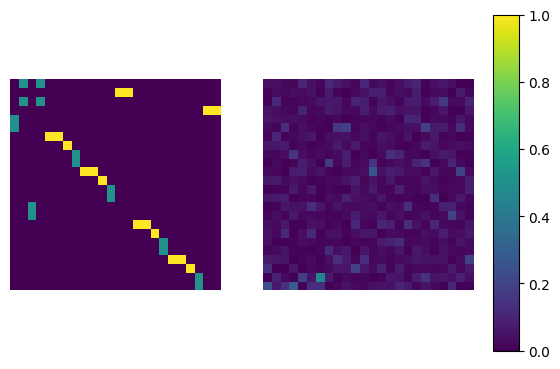

In [ ]:
## Plot Transition matrix learning            

'''
Plot 2 transition matrices side by side for result

Current notes : Where the model is supposed to give weight, it actually takes it away. Real transitions are becoming less likely. Local minimum or equation is shit? 

'''
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1,ncols=2)
sns.heatmap(A,cmap='viridis',vmin=0,vmax=1,ax=ax[0], cbar=False,square=True,annot=False,fmt='.1f',xticklabels=False, yticklabels=False)
matCB = sns.heatmap(cA,cmap='viridis',vmin=0,vmax=1,ax=ax[1], cbar=False,square=True,annot=False,fmt='.1f',xticklabels=False, yticklabels=False)
# matCB = ax[1].matshow(cA,cmap='viridis',vmin=0,vmax=1)

# add space for colour bar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
fig.colorbar(matCB.get_children()[0], cax=cbar_ax)




<Axes: >

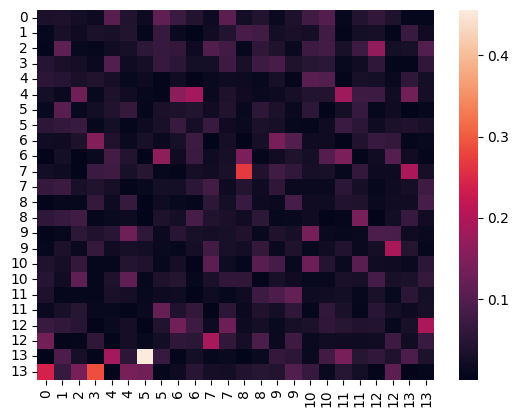

In [ ]:
sns.heatmap(cA)

#### Plot LogL of the model

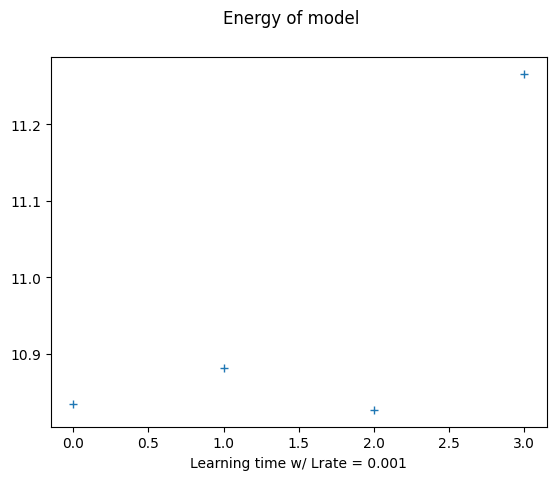

' L = E(joint) - Dkl(prior,true prior)\nActually, this is the evidence lower bound, not the log likelihood exactly - Basically model energy.\n: maybe compute it too to have it plotted, if possible. Otherwise plot model entropy only    \n'

In [ ]:
## Plot log likelihood of the model

# %matplotlib widget
import matplotlib.pyplot as plt
plt.close()
plt.plot(np.arange(0,Time[-1],step=1),LogL,'+')
plt.suptitle('Energy of model')
plt.xlabel(f'Learning time w/ Lrate = {Lrate}')
plt.show()

''' L = E(joint) - Dkl(prior,true prior)
Actually, this is the evidence lower bound, not the log likelihood exactly - Basically model energy.
: maybe compute it too to have it plotted, if possible. Otherwise plot model entropy only    
'''

In [ ]:
## Store for tests

h


,0,1,2,3,4,4,5,5,6,6,...,9,9,10,10,11,11,12,12,13,13
0,1.0,1.0,1.0,1.0,0.560753,0.439247,0.164318,0.835682,0.097887,0.902113,...,0.211642,0.788358,0.71877,0.28123,0.115168,0.884832,0.898031,0.101969,0.11863,0.88137


In [ ]:

LogL

[np.float64(10.834051336491923),
 np.float64(10.881313836083812),
 np.float64(10.826360298407051),
 np.float64(11.26581990730202)]